In [ ]:
!pip install kagglehub[pandas-datasets]


In [ ]:
!pip install os-sys


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of os-sys to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of os-sys to determine which version is compatible with other requirements. This could take a while.
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
#Sentiment

import kagglehub


In [ ]:
# Download latest version
path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'twitter-tweets-sentiment-dataset' dataset.
Path to dataset files: /kaggle/input/twitter-tweets-sentiment-dataset


In [ ]:
import os

In [ ]:
path = "/kaggle/input/twitter-tweets-sentiment-dataset"

In [ ]:
files = os.listdir(path)

In [ ]:
import pandas as pd

In [ ]:
file_path = os.path.join(path, "Tweets.csv")
df = pd.read_csv(file_path)

In [ ]:
print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [ ]:
df = (
	df.groupby('sentiment', group_keys=False)
  	.apply(lambda x: x.sample(n=200, random_state=42))
  	.reset_index(drop=True)
)


/tmp/ipykernel_3007/1271911122.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=200, random_state=42))


In [ ]:
print(df['sentiment'].value_counts())


sentiment
negative    200
neutral     200
positive    200
Name: count, dtype: int64


In [ ]:
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove @mentions and hashtags
    text = re.sub(r"@\w+|#\w+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove underscores (from \w)
    text = re.sub(r"_", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply to dataframe
df["clean_text"] = df["text"].apply(clean_text)

df[['clean_text', "text"]]

,clean_text,text
0,says bad trip angry,says BAD TRIP! (angry) http://plurk.com/p/wxshi
1,that sounds foreboding,that sounds foreboding...
2,kat i ve begged my mum to lt me get them out t...,_kat I`ve begged my mum to lt me get them out...
3,is really really bored i guess i will go to bed,"is really, really bored... I guess I will go t..."
4,i just stuck my finger down my throat and ther...,I just stuck my finger down my throat and ther...
...,...,...
595,omg amazing twist this is a crazy awesome movie,Omg amazing twist! This is a crazy awesome movie
596,haha aww hun i bet you are more creative than me,haha aww hun i bet you are more creative tha...
597,i love you but i can t call you cause i live i...,i love you but i can`t call you cause i live ...
598,i m not sure what stracchino is but it sounds ...,"i`m not sure what stracchino is, but it sound..."


In [ ]:
from nltk.corpus import stopwords


In [ ]:
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df["clean_text"] = df["clean_text"].apply(
	lambda x: " ".join(word for word in x.split() if word not in stop_words)
)


In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
	accuracy_score,
	f1_score,
	classification_report,
	confusion_matrix,
	ConfusionMatrixDisplay,
)

import torch
from torch.utils.data import Dataset

from transformers import (
	DistilBertTokenizerFast,  	# converts words → numbers
	DistilBertForSequenceClassification,  # the pre-trained model
	Trainer,                  	# handles the training loop for us
	TrainingArguments,        	# all the training settings
)

import matplotlib.pyplot as plt

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
training_df = df[['clean_text', "sentiment"]]

label_encoder = LabelEncoder()
training_df["label"] = label_encoder.fit_transform(training_df["sentiment"])

NUM_LABELS = len(label_encoder.classes_)

print("✅ Labels encoded!")
print(f"   Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"   Number of classes: {NUM_LABELS}\n")

✅ Labels encoded!
   Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
   Number of classes: 3



/tmp/ipykernel_3007/3522738545.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_df["label"] = label_encoder.fit_transform(training_df["sentiment"])


In [ ]:
# DistilBERT has its own vocabulary.
# The tokenizer breaks each sentence into subword pieces and
# returns two things:
#   input_ids  	— the ID of each token in the vocabulary
#   attention_mask — 1 = real token, 0 = padding (ignore this slot)

MODEL_NAME = "distilbert-base-uncased"
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128   # maximum number of tokens per sentence

texts  = training_df["clean_text"].tolist()
labels = training_df["label"].tolist()

encodings = tokenizer(
	texts,
	truncation=True,  	# cut sentences longer than MAX_LENGTH
	padding=True,     	# pad shorter sentences with zeros
	max_length=MAX_LENGTH,
	return_tensors="pt",  # return PyTorch tensors
)

print("✅ Text tokenized!")
print(f"   input_ids shape:  	{encodings['input_ids'].shape}")
print(f"   attention_mask shape: {encodings['attention_mask'].shape}\n")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Text tokenized!
   input_ids shape:  	torch.Size([600, 39])
   attention_mask shape: torch.Size([600, 39])



In [ ]:
# We hold back 20 % of the data to test on later.
# The model NEVER sees test data during training.

indices = list(range(len(labels)))

train_idx, test_idx = train_test_split(
	indices,
	test_size=0.2,
	random_state=42,       	# for reproducibility
	stratify=labels,       	# keep class balance in both splits
)

print("✅ Data split!")
print(f"   Training samples: {len(train_idx)}")
print(f"   Test samples: 	{len(test_idx)}\n")


✅ Data split!
   Training samples: 480
   Test samples: 	120



In [ ]:
# The Trainer needs a Dataset object.
# This class simply packages our tokens and labels together.

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels, indices):
        self.input_ids = encodings["input_ids"][indices]
        self.attention_mask = encodings["attention_mask"][indices]
        self.labels = torch.tensor([labels[i] for i in indices])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

train_dataset = SentimentDataset(encodings, labels, train_idx)
test_dataset = SentimentDataset(encodings, labels, test_idx)

print("✅ Datasets created!")
print(f"   Train size: {len(train_dataset)}   Test size: {len(test_dataset)}\n")

✅ Datasets created!
   Train size: 480   Test size: 120



In [ ]:
# We load DistilBERT with a fresh classification head on top.
# The model was already trained on millions of sentences (Wikipedia).
# We just add our sentiment classes and fine-tune.

model = DistilBertForSequenceClassification.from_pretrained(
	MODEL_NAME,
	num_labels=NUM_LABELS,
)

print("✅ Model loaded!")
total_params = sum(p.numel() for p in model.parameters())
print(f"   Total parameters: {total_params:,}\n")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded!
   Total parameters: 66,955,779



In [ ]:
training_args = TrainingArguments(
	output_dir="./results",
	num_train_epochs=3,
	per_device_train_batch_size=8,
	per_device_eval_batch_size=8,
	warmup_steps=10,
	weight_decay=0.01,
	eval_strategy="epoch",
	save_strategy="epoch",      	# ← this line was missing
	logging_dir="./logs",
	logging_steps=5,
	load_best_model_at_end=True,
	metric_for_best_model="accuracy",
	report_to="none",
)

print("✅ Training arguments set!\n")


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training arguments set!



In [ ]:
# This function is called after every epoch so we can
# see how the model is doing during training.

def compute_metrics(eval_pred):
	logits, true_labels = eval_pred
	predictions = np.argmax(logits, axis=-1)   # pick the highest score
	acc = accuracy_score(true_labels, predictions)
	f1  = f1_score(true_labels, predictions, average="weighted")
	return {"accuracy": acc, "f1": f1}


In [ ]:
# The Trainer handles:
#   • forward pass (predict)
#   • loss calculation (how wrong we were)
#   • backward pass (adjust weights)
#   • evaluation at each epoch

trainer = Trainer(
	model=model,
	args=training_args,
	train_dataset=train_dataset,
	eval_dataset=test_dataset,
	compute_metrics=compute_metrics,
)

print("🚀 Starting training …")
trainer.train()
print("\n✅ Training complete!\n")


🚀 Starting training …


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.084357,1.016852,0.541667,0.447691
2,0.707813,0.834525,0.625000,0.625855
3,0.505823,0.844645,0.641667,0.644154


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

In [ ]:
import kagglehub

DATASET_NAME = "yasserh/twitter-tweets-sentiment-dataset"
dataset_path = kagglehub.dataset_download(DATASET_NAME)
print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))

csv_path = os.path.join(dataset_path, "Tweets.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'twitter-tweets-sentiment-dataset' dataset.
Dataset path: /kaggle/input/twitter-tweets-sentiment-dataset
Files: ['Tweets.csv']
Shape: (27481, 4)


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
print(df.columns.tolist())
print(df["sentiment"].value_counts())
print(df[["text", "sentiment"]].head())

['textID', 'text', 'selected_text', 'sentiment']
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64
                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"<.*?>", " ", text)              # remove HTML
    text = re.sub(r"http\S+|www\S+", " ", text)    # remove URLs
    text = re.sub(r"@\w+", " ", text)              # remove mentions
    text = re.sub(r"#\w+", " ", text)              # remove hashtags
    text = re.sub(r"\d+", " ", text)               # remove numbers
    text = re.sub(r"[^\w\s]", " ", text)          # remove punctuation
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()       # normalize spaces
    return text


df = df[["text", "sentiment"]].copy()
df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text", "sentiment"]].head())


                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                                          clean_text sentiment  
0                 i d have responded if i were going   neutral  
1         sooo sad i will miss you here in san diego  negative  
2                             my boss is bullying me  negative  
3                      what interview leave me alone  negative  
4  sons of why couldn t they put them on the rele...  negative  


In [ ]:
N_PER_CLASS = 200

balanced_df = (
    df.groupby("sentiment", group_keys=False)
      .sample(n=N_PER_CLASS, random_state=SEED)
      .reset_index(drop=True)
)

print(balanced_df["sentiment"].value_counts())
print("Balanced shape:", balanced_df.shape)
balanced_df.head()

sentiment
negative    200
neutral     200
positive    200
Name: count, dtype: int64
Balanced shape: (600, 3)


,text,sentiment,clean_text
0,says BAD TRIP! (angry) http://plurk.com/p/wxshi,negative,says bad trip angry
1,that sounds foreboding...,negative,that sounds foreboding
2,_kat I`ve begged my mum to lt me get them out...,negative,_kat i ve begged my mum to lt me get them out ...
3,"is really, really bored... I guess I will go t...",negative,is really really bored i guess i will go to bed
4,I just stuck my finger down my throat and ther...,negative,i just stuck my finger down my throat and ther...


In [ ]:
training_df = balanced_df[["clean_text", "sentiment"]].copy()

label_encoder = LabelEncoder()
training_df["label"] = label_encoder.fit_transform(training_df["sentiment"])

X = training_df["clean_text"]
y = training_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Train size: 480
Test size: 120
Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [ ]:
def evaluate_model(model_name, y_true, y_pred, label_encoder, show_matrix=True):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    kappa = cohen_kappa_score(y_true, y_pred)
    agreement = np.mean(np.array(y_true) == np.array(y_pred))

    print(f"\n===== {model_name} =====")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    print("Kappa    :", round(kappa, 4))
    print("Agreement:", round(agreement, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    ))
    if show_matrix:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=label_encoder.classes_,
        )
        disp.plot()
        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Cohen_Kappa": kappa,
        "Agreement": agreement,
    }


===== TF-IDF + SVM =====
Accuracy : 0.5
Precision: 0.4947
Recall   : 0.5
F1-score : 0.4968
Kappa    : 0.25
Agreement: 0.5

Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.60      0.59        40
     neutral       0.39      0.35      0.37        40
    positive       0.52      0.55      0.54        40

    accuracy                           0.50       120
   macro avg       0.49      0.50      0.50       120
weighted avg       0.49      0.50      0.50       120



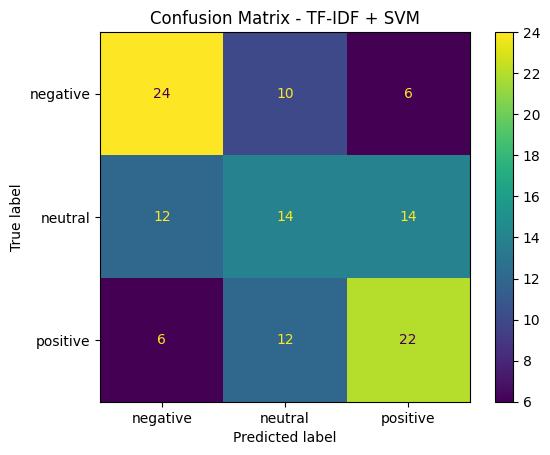

In [ ]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("clf", LinearSVC()),
])

svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

svm_results = evaluate_model("TF-IDF + SVM", y_test, svm_preds, label_encoder)



===== TF-IDF + Logistic Regression =====
Accuracy : 0.4917
Precision: 0.4864
Recall   : 0.4917
F1-score : 0.4881
Kappa    : 0.2375
Agreement: 0.4917

Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.57      0.56        40
     neutral       0.40      0.35      0.37        40
    positive       0.51      0.55      0.53        40

    accuracy                           0.49       120
   macro avg       0.49      0.49      0.49       120
weighted avg       0.49      0.49      0.49       120



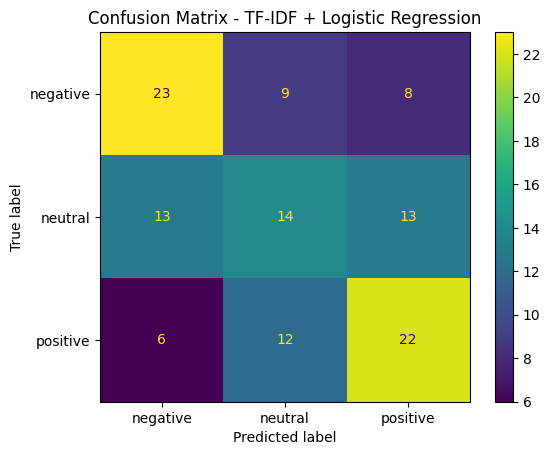

In [ ]:
logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000)),
])

logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)

logreg_results = evaluate_model("TF-IDF + Logistic Regression", y_test, logreg_preds, label_encoder)



===== TF-IDF + Logistic Regression =====
Accuracy : 0.4917
Precision: 0.4864
Recall   : 0.4917
F1-score : 0.4881
Kappa    : 0.2375
Agreement: 0.4917

Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.57      0.56        40
     neutral       0.40      0.35      0.37        40
    positive       0.51      0.55      0.53        40

    accuracy                           0.49       120
   macro avg       0.49      0.49      0.49       120
weighted avg       0.49      0.49      0.49       120



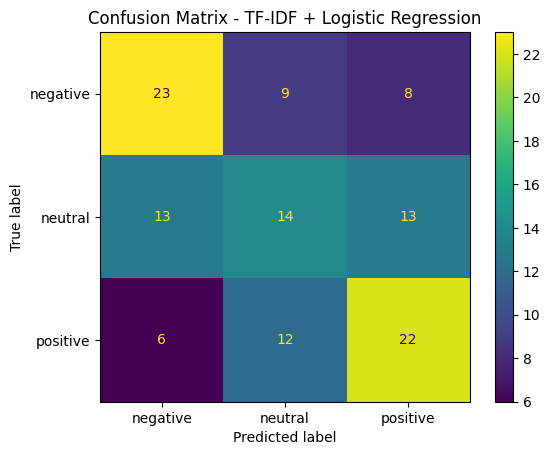

In [ ]:
logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=2000)),
])

logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)

logreg_results = evaluate_model("TF-IDF + Logistic Regression", y_test, logreg_preds, label_encoder)


In [ ]:
from transformers import DistilBertTokenizerFast

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

train_texts = X_train.tolist()
test_texts = X_test.tolist()
train_labels = y_train.tolist()
test_labels = y_test.tolist()

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
)

print("Tokenization complete.")
print("Train samples:", len(train_texts))
print("Test samples:", len(test_texts))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete.
Train samples: 480
Test samples: 120


In [ ]:
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

print("Datasets ready:", len(train_dataset), len(test_dataset))

Datasets ready: 480 120


In [ ]:
from transformers import DistilBertForSequenceClassification

bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_),
)

print("DistilBERT loaded.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0,
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0,
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    weight_decay=0.01,
    warmup_steps=10,
    logging_steps=10,
    report_to="none",
)

print("Training arguments ready.")

Training arguments ready.


In [ ]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Starting DistilBERT training...")
trainer.train()
print("Training finished.")

Starting DistilBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.936124,0.842979,0.641667,0.652986,0.641667,0.593061
2,0.529824,0.793335,0.616667,0.670397,0.616667,0.620380
3,0.296170,0.786084,0.691667,0.688673,0.691667,0.689289


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training finished.
